In [1]:
words = open('names.txt', 'r').read().splitlines()
words[:20]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett']

In [2]:
len(words)

32033

In [3]:
min(len(w) for w in words)

2

In [4]:
max(len(w) for w in words)

15

In [26]:
b = {}
for w in words:
    chs = ['<s>'] + list(w) + ['<e>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1, ch2)

In [27]:
# sorted(b.items(), key = lambda kv: -kv[1])

In [28]:
import torch

In [29]:
N = torch.zeros((27,27), dtype=torch.int32)

In [30]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [31]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [33]:
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

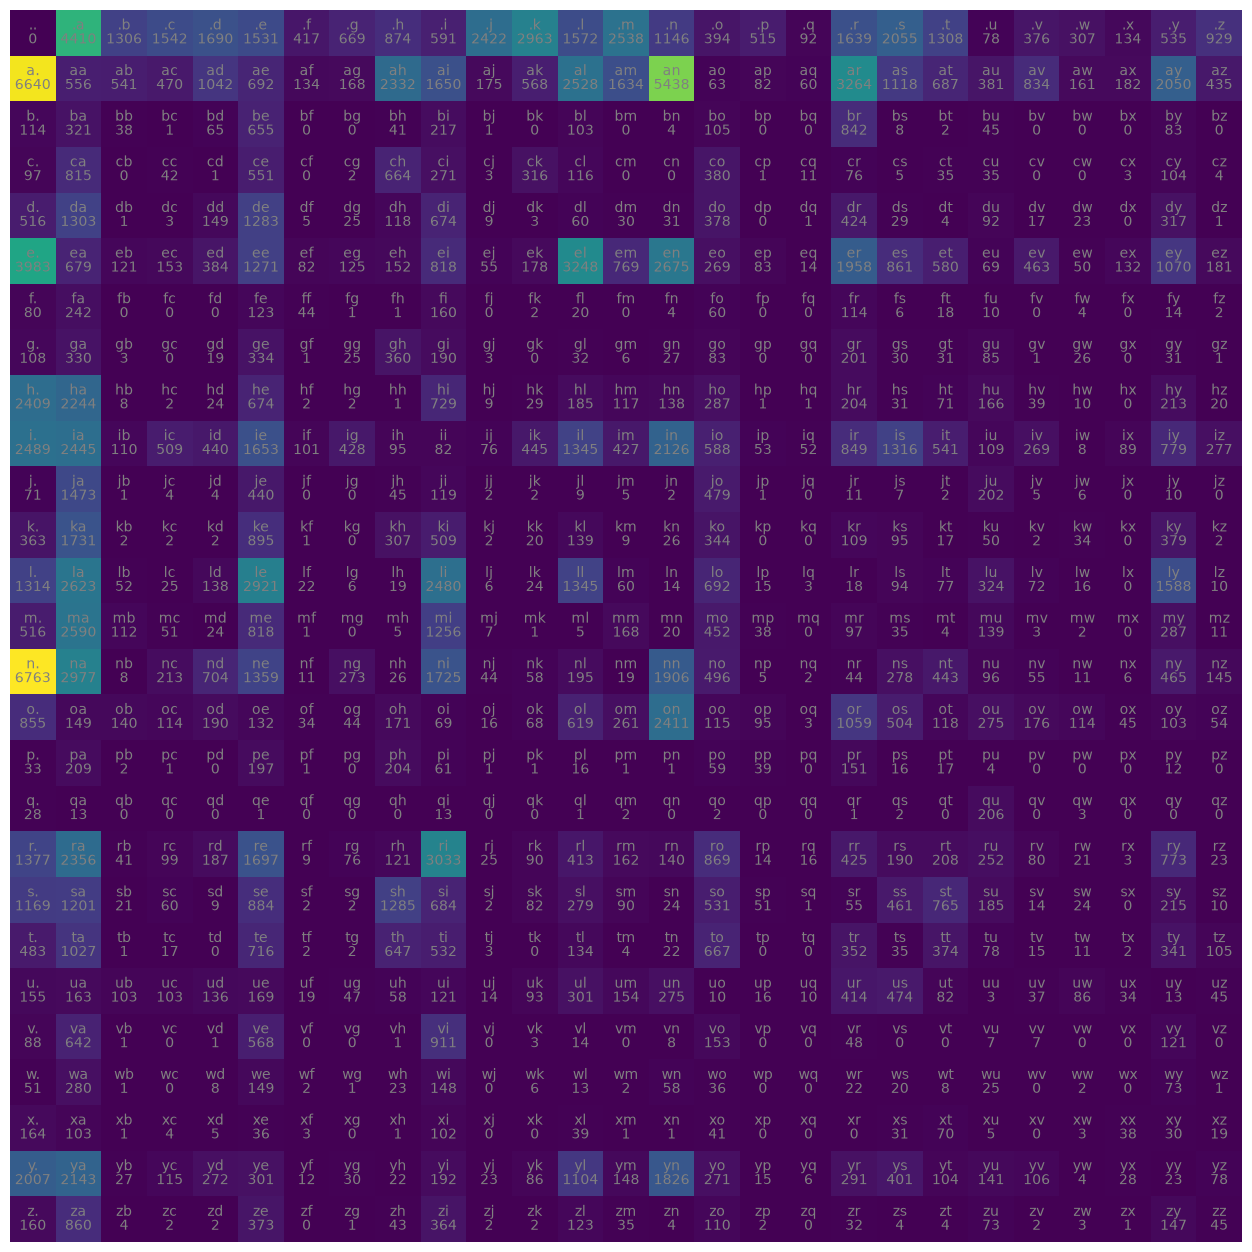

In [35]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis("off")

plt.imshow(N)


In [57]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [70]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'.'

In [64]:
g = torch.Generator().manual_seed(2147483647)
# print(g.device)
p = torch.rand(3, generator=g)
p = p / p.sum()
p


tensor([0.6064, 0.3033, 0.0903])

In [66]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([0, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        2, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
        1, 0, 2, 0])

In [92]:
g = torch.Generator(device='cuda').manual_seed(2147483647)

for i in range(50):
    out = []
    ix = 0
    while True:
        
        p = N[ix].float()
        p = p/p.sum()
        # p = torch.ones(27) / 27.0
    
        p = p.to('cuda')
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        # print(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
    

khe.
ke.
wylilmorilageli.
ahan.
ramalyama.
xonndafrinerimienlill.
ermale.
can.
anynale.
zon.
lyaylily.
disosheloell.
tette.
sanism.
malyaiannayle.
s.
jayantahablig.
d.
malana.
sh.
ka.
gel.
rahayesoulykorlawyletelelen.
jale.
bryalenelearin.
ayn.
maha.
l.
sth.
kiy.
tigh.
keyndini.
n.
madeendrkrlth.
lalad.
li.
brux.
ariarumilim.
shze.
nvi.
eenicharayama.
ron.
s.
keeron.
dulya.
aite.
mith.
vaht.
se.
browiy.
